In [1]:
import xarray as xr
from glob import glob
from datetime import datetime
import yaml
import sys
sys.path.append('../../')

import plotting

from conf.global_settings import OUTPUT_DIR
from utils.pipeline_utils.file_utils import get_date
from transformations.grid_transformation import Transformation

In [2]:
ds_name = "NASA_SSH_REF_SIMPLE_GRID_V11"
hemisphere = ''
with open(f'conf/ds_configs/{ds_name}.yaml', 'r') as stream:
    config = yaml.load(stream, yaml.Loader)

# Load sample granule

In [3]:
ds_granules_dir = f'{OUTPUT_DIR}/{ds_name}/harvested_granules/'
ds_granules = glob(f'{ds_granules_dir}/**/*.nc*')
if hemisphere:
    ds_granules = [g for g in ds_granules if hemisphere in g]
sample_granule_path = ds_granules[0]
print(sample_granule_path)

/Users/marlis/Developer/ECCO/ecco_output/NASA_SSH_REF_SIMPLE_GRID_V11/harvested_granules/2026/NASA-SSH_alt_ref_simple_grid_v1_1_20260518.nc


In [4]:
filename_date_str = get_date(config['filename_date_regex'], sample_granule_path.split('/')[-1])
granule_date = datetime.strptime(filename_date_str, config['filename_date_fmt']).strftime('%Y-%m-%dT%H:%M:%SZ')
ds = xr.open_dataset(sample_granule_path)
ds

<xarray.Dataset>
Dimensions:            (latitude: 360, longitude: 720, basins: 293)
Coordinates:
  * latitude           (latitude) float32 -89.75 -89.25 -88.75 ... 89.25 89.75
  * longitude          (longitude) float32 0.25 0.75 1.25 ... 358.8 359.2 359.8
Dimensions without coordinates: basins
Data variables:
    ssha               (latitude, longitude) float64 ...
    basin_flag         (latitude, longitude) float64 ...
    counts             (latitude, longitude) float64 ...
    time               datetime64[ns] ...
    basin_names_table  (basins) <U33 ...
Attributes: (12/37)
    Conventions:               CF-1.9
    title:                     NASA-SSH Simple Gridded Sea Surface Height fro...
    summary:                   This data set contains satellite based measure...
    acknowledgement:           This data is provided by NASAs PO.DAAC.
    license:                   https://creativecommons.org/licenses/by/4.0/
    geospatial_lat_max:        90.0
    ...                        ...
    mean_sea_surface:          DTU21
    gridding_method:           Gridded using pyresample resample_gauss with r...
    time_coverage_start:       2026-05-13T00:00:00
    time_coverage_end:         2026-05-23T00:00:00
    source_files:              NASA-SSH_alt_ref_at_v1_1_20260513.nc, NASA-SSH...
    source_valid_points:       521648

# Load grid

In [5]:
grids = glob(f'grids/*.nc*')
grids.sort()
f'Available grids: {grids}'

"Available grids: ['grids/ECCO_llc270.nc', 'grids/ECCO_llc90.nc', 'grids/TPOSE.nc', 'grids/polar_stereo_n_25km.nc']"

In [6]:
grid_ds = xr.open_dataset(grids[1])
grid_ds

<xarray.Dataset>
Dimensions:                (tile: 13, j: 90, i: 90)
Coordinates:
  * tile                   (tile) int16 0 1 2 3 4 5 6 7 8 9 10 11 12
  * j                      (j) int16 0 1 2 3 4 5 6 7 ... 82 83 84 85 86 87 88 89
  * i                      (i) int16 0 1 2 3 4 5 6 7 ... 82 83 84 85 86 87 88 89
Data variables:
    XC                     (tile, j, i) float32 ...
    YC                     (tile, j, i) float32 ...
    effective_grid_radius  (tile, j, i) float32 ...
Attributes:
    name:                  ECCO_llc90
    type:                  llc
    geospatial_lat_min:    -89.873055
    geospatial_lat_max:    89.739395
    geospatial_lon_min:    -179.98895
    geospatial_lon_max:    179.98691
    geospatial_lat_units:  degrees_north
    geospatial_lon_units:  degrees_east

In [7]:
T = Transformation(config, sample_granule_path, granule_date)

# Make mapping factors

In [8]:
factors = T.make_factors(grid_ds)

/Users/marlis/miniforge3/envs/ecco_pipeline/lib/python3.10/site-packages/pyproj/crs/crs.py:1286: UserWarning: You will likely lose important projection information when converting to a PROJ string from another format. See: https://proj.org/faq.html#what-is-the-best-format-for-describing-coordinate-reference-systems
  proj = self._crs.to_proj4(version=version)


Only using 100 nearest neighbours, but you may need up to 398498
Creating ECCO_llc90 mapping factors...done.


# Transformation

In [9]:
field_ds_list = T.transform(grid_ds, factors, ds)

In [10]:
field_ds = field_ds_list[0][0]
field_ds

<xarray.Dataset>
Dimensions:                          (time: 1, tile: 13, j: 90, i: 90, nv: 2)
Coordinates:
  * time                             (time) datetime64[ns] 2026-05-18T12:00:00
  * tile                             (tile) int16 0 1 2 3 4 5 6 7 8 9 10 11 12
  * j                                (j) int16 0 1 2 3 4 5 ... 84 85 86 87 88 89
  * i                                (i) int16 0 1 2 3 4 5 ... 84 85 86 87 88 89
    XC                               (tile, j, i) float32 -111.6 ... -111.9
    YC                               (tile, j, i) float32 -88.24 ... -88.1
    time_bnds                        (time, nv) datetime64[ns] 2026-05-18 202...
Dimensions without coordinates: nv
Data variables:
    ssha_interpolated_to_ECCO_llc90  (time, tile, j, i) float64 9.969e+36 ......
Attributes:
    interpolated_grid:            ECCO_llc90
    model_grid_type:              llc
    original_dataset_title:       NASA-SSH Simple Gridded Sea Surface Height ...
    original_dataset_short_name:  NASA_SSH_REF_SIMPLE_GRID_V11
    original_dataset_url:         https://podaac.jpl.nasa.gov/dataset/NASA_SS...
    original_dataset_reference:   https://archive.podaac.earthdata.nasa.gov/p...
    original_dataset_doi:         10.5067/NSREF-SG0V11
    interpolated_grid_id:         ECCO_llc90
    transformation_version:       1.0
    notes:

# Visualization

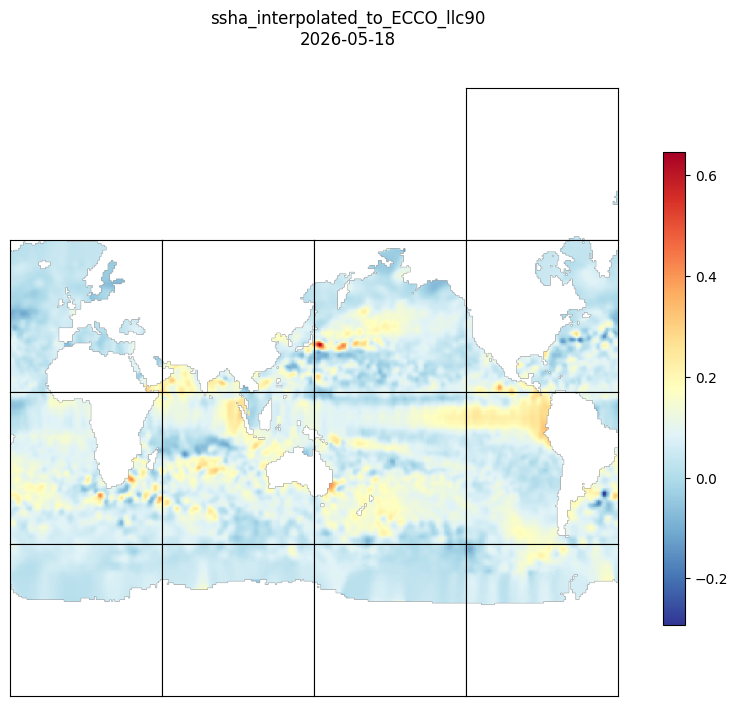

In [11]:
for field_ds in field_ds_list:
    plotting.make_plot(field_ds[0][list(field_ds[0].data_vars)[0]])
